# 📚 Hybrid Graph-Vector RAG for Books
### A Step-by-Step Learning Notebook

This notebook builds a state-of-the-art RAG pipeline for long-form narrative content **from scratch**.
Instead of wrapping everything in a framework, we build each concept manually so you understand *why* each piece exists.

**Pipeline overview:**
```
EPUB
  │
  ├── Part 1: Parse → Chapters
  ├── Part 2: Hierarchical Chunking → Chapter > Scene > Paragraph nodes
  ├── Part 3: Chapter Summaries (Claude)
  ├── Part 4: Contextual Embeddings → enriched leaf chunks
  ├── Part 5: Vector Index (numpy) + retrieval
  ├── Part 6: Auto-Merging Retrieval
  ├── Part 7: Entity Extraction → Knowledge Graph
  └── Part 8: Hybrid Query + Generation
```

**We use one book**: Red Rising (book 0). Small enough to iterate fast, complex enough to test the pipeline.

## 0. Setup

Install any packages not already in the project venv.

In [2]:
# Install packages we'll need beyond the project's existing deps
# Run this once; comment out after the first successful run
!poetry add networkx matplotlib llama-index-core llama-index-llms-anthropic llama-index-embeddings-huggingface 

Using version ^3.6.1 for networkx
Using version ^3.10.9 for matplotlib
Using version ^0.14.22 for llama-index-core
Using version ^0.11.5 for llama-index-llms-anthropic
Using version ^0.7.0 for llama-index-embeddings-huggingface

Updating dependencies
Resolving dependencies... (2.6s)Resolving dependencies... (0.3s)

Package operations: 30 installs, 3 updates, 0 removals

  - Installing colorama (0.4.6): Pending...
  - Installing griffelib (2.0.2): Pending...
  - Installing jmespath (1.1.0): Pending...
  - Installing wrapt (2.2.1): Pending...
  - Installing wrapt (2.2.1): Pending...
  - Installing jmespath (1.1.0): Downloading... 0%
  - Installing wrapt (2.2.1): Pending...
  - Installing wrapt (2.2.1): Downloading... 0%
  - Installing jmespath (1.1.0): Downloading... 0%
  - Installing wrapt (2.2.1): Downloading... 0%
  - Installing griffelib (2.0.2): Downloading... 0%
  - Installing jmespath (1.1.0): Downloading... 0%
  - Installing wrapt (2.2.1): Downloading... 0%
  - Installing wrapt (

In [29]:
import sys
import os
import re
import json
import textwrap
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from dotenv import load_dotenv

# Make project src importable
sys.path.insert(0, str(Path.cwd()))
load_dotenv()

# Quick sanity check
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY", "")
print(f"Anthropic key present: {bool(ANTHROPIC_API_KEY)}")
print("Setup complete.")

Anthropic key present: True
Setup complete.


In [30]:
# ── LLM Output Cache ──────────────────────────────────────────────────────────
# All expensive LLM calls (summaries, extractions, coreference) are cached as
# JSON files under CACHE_DIR. Set OVERWRITE = True to force a fresh run.

CACHE_DIR = Path("notebook_llm_cache")
OVERWRITE  = False   # ← flip to True to regenerate everything

CACHE_DIR.joinpath("summaries").mkdir(parents=True, exist_ok=True)
CACHE_DIR.joinpath("extractions").mkdir(parents=True, exist_ok=True)


def _cache_path(subdir: str, key: str) -> Path:
    safe_key = re.sub(r"[^\w\-.]", "_", key)
    return CACHE_DIR / subdir / f"{safe_key}.json"


def cache_read(subdir: str, key: str):
    """Return parsed JSON from cache, or None if missing / OVERWRITE is set."""
    if OVERWRITE:
        return None
    p = _cache_path(subdir, key)
    if p.exists():
        return json.loads(p.read_text())
    return None


def cache_write(subdir: str, key: str, data) -> None:
    """Persist data as JSON to cache."""
    p = _cache_path(subdir, key)
    p.write_text(json.dumps(data, indent=2))


print(f"Cache dir : {CACHE_DIR.resolve()}")
print(f"OVERWRITE : {OVERWRITE}")
print("Cache utilities ready.")

Cache dir : /Users/aravi/Documents/Workspace/Projects/book-lens/notebook_llm_cache
OVERWRITE : False
Cache utilities ready.


## Part 1 — Parse the Book

We already have an epub parser in the project. Let's use it and understand what it gives us.

**What `parse_epub` returns:**
- A list of `ParsedChapter` objects, each with:
  - `index` — 0-based position
  - `label` — chapter title from TOC
  - `text` — raw text with `\n\n` paragraph separators

In [31]:
from src.ingestion.epub_parser import parse_epub

BOOK_PATH = Path("uploads/red-rising/book_0.epub")
chapters = parse_epub(BOOK_PATH)

print(f"Parsed {len(chapters)} chapters")
print(f"\nFirst 5 chapters:")
for ch in chapters[:5]:
    word_count = len(ch.text.split())
    print(f"  [{ch.index:2d}] {ch.label:<35} {word_count:,} words")

Parsed 50 chapters

First 5 chapters:
  [ 0] Prologue                            269 words
  [ 1] 1: Helldiver                        2,260 words
  [ 2] 2: The Township                     3,417 words
  [ 3] 3: The Laurel                       2,801 words
  [ 4] 4: The Gift                         2,736 words


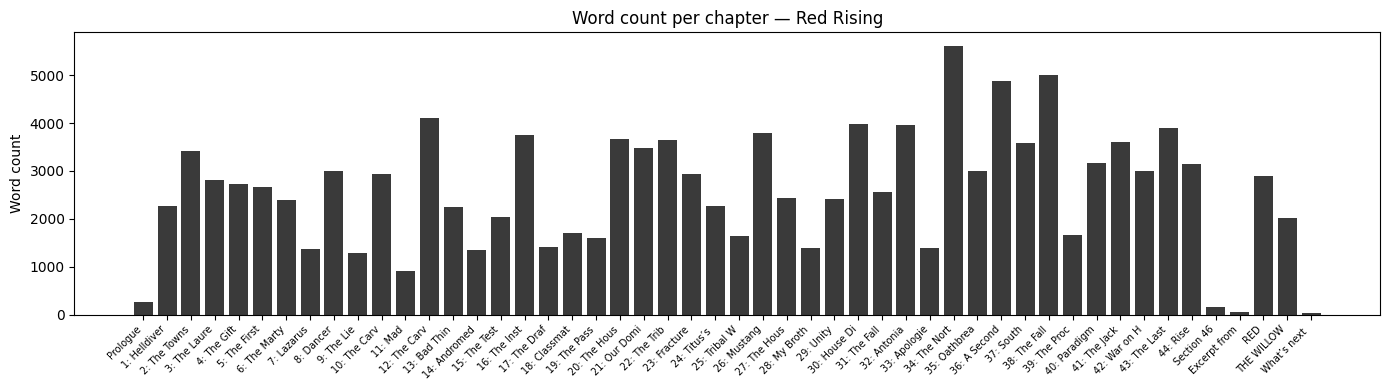

Total words: 129,545
Avg words/chapter: 2,590


In [32]:
# Visualise word counts across the book
labels = [ch.label for ch in chapters]
word_counts = [len(ch.text.split()) for ch in chapters]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(chapters)), word_counts, color="#3a3a3a", width=0.8)
ax.set_xticks(range(len(chapters)))
ax.set_xticklabels([c.label[:12] for c in chapters], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Word count")
ax.set_title("Word count per chapter — Red Rising")
plt.tight_layout()
plt.show()

print(f"Total words: {sum(word_counts):,}")
print(f"Avg words/chapter: {sum(word_counts)//len(chapters):,}")

In [33]:
# Preview a chapter — look at the raw structure
ch = chapters[1]  # Chapter 1
paragraphs = [p.strip() for p in ch.text.split("\n\n") if p.strip()]

print(f"Chapter: {ch.label}")
print(f"Paragraphs: {len(paragraphs)}")
print(f"\n--- First 3 paragraphs ---")
for i, para in enumerate(paragraphs[:3]):
    print(f"\n[P{i}] ({len(para.split())} words)")
    print(textwrap.fill(para[:300], width=80))

Chapter: 1: Helldiver
Paragraphs: 62

--- First 3 paragraphs ---

[P0] (1 words)
1

[P1] (1 words)
HELLDIVER

[P2] (124 words)
The first thing you should know about me is I am my father’s son. And when they
came for him, I did as he asked. I did not cry. Not when the Society televised
the arrest. Not when the Golds tried him. Not when the Grays hanged him. Mother
hit me for that. My brother Kieran was supposed to be the sto


## Part 2 — Hierarchical Chunking

### The Problem with Naive Chunking

Most RAG tutorials split text by fixed token counts (e.g., every 256 tokens). For books, this is terrible because:
1. A chunk might start mid-sentence or mid-scene
2. No context about *where* in the story we are
3. Retrieval returns isolated fragments that don't make sense alone

### The Solution: Hierarchical Node Tree

```
Chapter (root node)         ← ~3,000-8,000 words, has summary
  ├── Scene (intermediate)  ← ~500-1,500 words, natural break
  │     ├── Paragraph       ← ~50-200 words, leaf node, what we embed
  │     └── Paragraph
  └── Scene
        ├── Paragraph
        └── Paragraph
```

**Key insight**: We embed the LEAF nodes (paragraphs), but each leaf knows its parent (scene) and grandparent (chapter). When we retrieve leaves, we can *merge up* to return the full scene for better context.

In [7]:
@dataclass
class TextNode:
    """A node in the hierarchical chunk tree."""
    id: str                          # e.g. "ch01_scene02_para03"
    text: str
    level: str                       # "chapter", "scene", or "paragraph"
    chapter_index: int
    chapter_label: str
    scene_index: Optional[int] = None
    para_index: Optional[int] = None
    parent_id: Optional[str] = None  # Link to parent node
    chapter_summary: Optional[str] = None  # Added later
    embedding: Optional[np.ndarray] = None  # Added later


def split_into_scenes(paragraphs: List[str], target_words: int = 600) -> List[List[str]]:
    """
    Group paragraphs into scenes by greedy accumulation.
    A new scene starts when the accumulated text exceeds target_words.
    We never split a paragraph across scenes.
    """
    scenes: List[List[str]] = []
    current: List[str] = []
    current_words = 0

    for para in paragraphs:
        para_words = len(para.split())
        # Start a new scene if we've hit the target AND the current scene is non-empty
        if current_words >= target_words and current:
            scenes.append(current)
            current = []
            current_words = 0
        current.append(para)
        current_words += para_words

    if current:
        scenes.append(current)

    return scenes


def build_hierarchy(chapters) -> Dict[str, TextNode]:
    """Build the full Chapter→Scene→Paragraph node tree."""
    nodes: Dict[str, TextNode] = {}

    for ch in chapters:
        # --- Chapter-level (root) node ---
        ch_id = f"ch{ch.index:03d}"
        ch_node = TextNode(
            id=ch_id,
            text=ch.text,
            level="chapter",
            chapter_index=ch.index,
            chapter_label=ch.label,
        )
        nodes[ch_id] = ch_node

        # Split chapter into paragraphs, then group into scenes
        paragraphs = [p.strip() for p in ch.text.split("\n\n") if len(p.strip()) > 30]
        scenes = split_into_scenes(paragraphs, target_words=600)

        for s_idx, scene_paras in enumerate(scenes):
            # --- Scene-level (intermediate) node ---
            sc_id = f"{ch_id}_sc{s_idx:02d}"
            sc_node = TextNode(
                id=sc_id,
                text="\n\n".join(scene_paras),
                level="scene",
                chapter_index=ch.index,
                chapter_label=ch.label,
                scene_index=s_idx,
                parent_id=ch_id,
            )
            nodes[sc_id] = sc_node

            for p_idx, para_text in enumerate(scene_paras):
                # --- Paragraph-level (leaf) node ---
                para_id = f"{sc_id}_p{p_idx:02d}"
                para_node = TextNode(
                    id=para_id,
                    text=para_text,
                    level="paragraph",
                    chapter_index=ch.index,
                    chapter_label=ch.label,
                    scene_index=s_idx,
                    para_index=p_idx,
                    parent_id=sc_id,
                )
                nodes[para_id] = para_node

    return nodes


# Build it!
nodes = build_hierarchy(chapters)

chapter_nodes = [n for n in nodes.values() if n.level == "chapter"]
scene_nodes   = [n for n in nodes.values() if n.level == "scene"]
para_nodes    = [n for n in nodes.values() if n.level == "paragraph"]

print(f"Total nodes: {len(nodes):,}")
print(f"  Chapter nodes : {len(chapter_nodes)}")
print(f"  Scene nodes   : {len(scene_nodes)}")
print(f"  Paragraph nodes: {len(para_nodes)}")
print(f"\nAvg scenes/chapter : {len(scene_nodes)/len(chapter_nodes):.1f}")
print(f"Avg paragraphs/scene: {len(para_nodes)/len(scene_nodes):.1f}")

Total nodes: 3,700
  Chapter nodes : 50
  Scene nodes   : 227
  Paragraph nodes: 3423

Avg scenes/chapter : 4.5
Avg paragraphs/scene: 15.1


In [8]:
# Inspect the hierarchy for Chapter 1
ch1_scenes = [n for n in scene_nodes if n.chapter_index == 1]
print(f"Chapter 1 has {len(ch1_scenes)} scenes")
print()

for scene in ch1_scenes[:3]:
    paras_in_scene = [n for n in para_nodes if n.parent_id == scene.id]
    print(f"Scene {scene.scene_index} — {len(paras_in_scene)} paragraphs, {len(scene.text.split())} words")
    print(f"  First para: {paras_in_scene[0].text[:100]}...")
    print()

Chapter 1 has 4 scenes

Scene 0 — 8 paragraphs, 604 words
  First para: The first thing you should know about me is I am my father’s son. And when they came for him, I did ...

Scene 1 — 22 paragraphs, 603 words
  First para: It is eerie in the deep tunnels. Lonely. Beyond the roar of the drill, I hear the voices of my frien...

Scene 2 — 15 paragraphs, 641 words
  First para: “Listen to Uncle Narol, Darrow. Better to back off till we can get a reading,”...



## Part 3 — Chapter Summarization

Before we embed anything, we need chapter summaries. Why?

**The decontextualization problem**: A paragraph like *"He drew his crysknife slowly"* has no context when embedded alone. Is this a battle? A ritual? Who is "he"?

We'll prepend each leaf's chapter summary to its text before embedding. This gives the model the "where in the story" context it needs.

**Cost note**: Summarizing all chapters uses LLM API calls. We'll process just the first 5 chapters here to keep costs low during exploration.

In [9]:
import anthropic

client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)


def summarise_chapter(chapter_text: str, chapter_label: str, book_title: str = "Red Rising") -> str:
    """Generate a 2-3 sentence chapter summary using Claude, with caching."""
    cache_key = f"ch_{chapter_label}"
    cached = cache_read("summaries", cache_key)
    if cached is not None:
        return cached["summary"]

    text_excerpt = " ".join(chapter_text.split()[:4000])
    response = client.messages.create(
        model="claude-haiku-4-5",
        max_tokens=200,
        messages=[
            {
                "role": "user",
                "content": (
                    f"Book: {book_title}\n"
                    f"Chapter: {chapter_label}\n\n"
                    f"{text_excerpt}\n\n"
                    "Write a 2-3 sentence summary of this chapter. "
                    "Include key character names, what happens, and the outcome. "
                    "Be specific — this summary is used internally to enrich embeddings, not shown to readers."
                ),
            }
        ],
    )
    summary = response.content[0].text.strip()
    cache_write("summaries", cache_key, {"summary": summary})
    return summary


CHAPTERS_TO_SUMMARISE = 5
summaries: Dict[int, str] = {}

print(f"Summarising first {CHAPTERS_TO_SUMMARISE} chapters...\n")
for ch in chapters[:CHAPTERS_TO_SUMMARISE]:
    cache_key = f"ch_{ch.label}"
    hit = not OVERWRITE and _cache_path("summaries", cache_key).exists()
    summary = summarise_chapter(ch.text, ch.label)
    summaries[ch.index] = summary
    status = "CACHED" if hit else "NEW"
    print(f"[Ch {ch.index}] [{status}] {ch.label}")
    print(f"  → {summary[:120]}...")
    print()

Summarising first 5 chapters...

[Ch 0] [NEW] Prologue
  → # Red Rising Prologue Summary

Darrow, a Red, observes a Golden instructor named Augustus addressing twelve hundred elit...

[Ch 1] [NEW] 1: Helldiver
  → # Red Rising - Chapter 1: Helldiver Summary

Darrow, a sixteen-year-old Red Helldiver in the Mars mining colonies, opera...

[Ch 2] [NEW] 2: The Township
  → # Red Rising - Chapter 2: The Township Summary

Darrow, a Red Helldiver, narrowly escapes a near-fatal accident in the m...

[Ch 3] [NEW] 3: The Laurel
  → # Chapter 3 Summary

Darrow and his wife Eo travel with their Red mining clan to the Laureltide celebration in the Commo...

[Ch 4] [NEW] 4: The Gift
  → # Chapter 4: The Gift Summary

Darrow and his wife Eo escape to a hidden forest dome to celebrate their love, where Eo r...



In [10]:
# Attach summaries to chapter and leaf nodes
for node in nodes.values():
    if node.chapter_index in summaries:
        node.chapter_summary = summaries[node.chapter_index]

# How many leaf nodes now have summaries?
leaves_with_summary = [n for n in para_nodes if n.chapter_summary]
print(f"Leaves with chapter summary: {len(leaves_with_summary)} / {len(para_nodes)}")

Leaves with chapter summary: 278 / 3423


## Part 4 — Contextual Embeddings

### Naive vs Contextual

| Approach | What you embed | Problem |
|----------|---------------|----------|
| Naive | `"He drew his crysknife slowly."` | No context — who, where, when? |
| Contextual | `"[Book: Red Rising | Chapter 1: Helldiver | Summary: Darrow, a Red miner on Mars, returns from a dangerous helldive. His world is defined by brutal hierarchy...] He drew his crysknife slowly."` | Vector captures story context |

The enriched prefix is only used for **generating the embedding** — it's NOT stored or returned in the retrieved text. We still return the clean paragraph text.

In [11]:
from sentence_transformers import SentenceTransformer

# Load the embedding model (downloads ~90MB on first run)
# all-MiniLM-L6-v2 is fast and good enough for prototyping
# Swap to "nomic-ai/nomic-embed-text-v1" for production quality
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

print(f"Embedding dimension: {embed_model.get_sentence_embedding_dimension()}")

/Users/aravi/Documents/Workspace/Projects/book-lens/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Embedding dimension: 384


In [12]:
def make_contextual_text(node: TextNode) -> str:
    """Enrich a leaf node's text with its chapter context for embedding."""
    prefix_parts = [f"Book: Red Rising", f"Chapter: {node.chapter_label}"]
    if node.chapter_summary:
        prefix_parts.append(f"Summary: {node.chapter_summary}")
    prefix = " | ".join(prefix_parts)
    return f"[{prefix}]\n{node.text}"


# Quick demo — compare naive vs contextual
sample_node = para_nodes[10]
print("=== NAIVE TEXT (what we'd embed without context) ===")
print(textwrap.fill(sample_node.text[:300], width=80))
print()
print("=== CONTEXTUAL TEXT (what we actually embed) ===")
print(textwrap.fill(make_contextual_text(sample_node)[:400], width=80))

=== NAIVE TEXT (what we'd embed without context) ===
The drillers of my clan chatter some gossip over the comm in my ear as I ride
atop the clawDrill. I’m alone in this deep tunnel on a machine built like a
titanic metal hand, one that grasps and gnaws at the ground. I control its
rockmelting digits from the holster seat atop the drill, just where the

=== CONTEXTUAL TEXT (what we actually embed) ===
[Book: Red Rising | Chapter: 1: Helldiver | Summary: # Red Rising - Chapter 1:
Helldiver Summary  Darrow, a sixteen-year-old Red Helldiver in the Mars mining
colonies, operates a massive clawDrill to extract helium-3 in the deep tunnels
below Lykos. When his uncle Narol orders him to wait for a sensor crew to check
a gas pocket, Darrow—driven by ambition to win the Laurel (a quarterly prize his
cl


In [13]:
# Embed all leaf nodes that have summaries (first 5 chapters)
# For the full book, remove the filter
leaves_to_embed = [n for n in para_nodes if n.chapter_summary]

print(f"Embedding {len(leaves_to_embed)} leaf nodes...")

contextual_texts = [make_contextual_text(n) for n in leaves_to_embed]
embeddings = embed_model.encode(contextual_texts, show_progress_bar=True, batch_size=64)

# Attach embeddings to nodes
for node, emb in zip(leaves_to_embed, embeddings):
    node.embedding = emb

print(f"\nEmbedding matrix shape: {embeddings.shape}")
print(f"Each vector: {embeddings.shape[1]} dimensions")

Embedding 278 leaf nodes...


Batches: 100%|██████████| 5/5 [00:01<00:00,  2.88it/s]


Embedding matrix shape: (278, 384)
Each vector: 384 dimensions


## Part 5 — Vector Index & Retrieval

We'll build a minimal vector store using numpy. No external database needed.
The core operation is **cosine similarity**: the angle between two vectors.
Vectors with small angles (cos → 1.0) are semantically similar.

In [14]:
class NumpyVectorIndex:
    """Minimal in-memory vector index backed by numpy."""

    def __init__(self, nodes: List[TextNode]):
        # Filter to nodes with embeddings
        self._nodes = [n for n in nodes if n.embedding is not None]
        # Stack into matrix: (N, D)
        matrix = np.stack([n.embedding for n in self._nodes])
        # Pre-normalize rows so dot product == cosine similarity
        norms = np.linalg.norm(matrix, axis=1, keepdims=True)
        self._matrix = matrix / norms  # (N, D)
        print(f"Index built: {len(self._nodes)} vectors, {self._matrix.shape[1]}d")

    def search(self, query: str, top_k: int = 5) -> List[Tuple[TextNode, float]]:
        """Return top_k most similar nodes for a query string."""
        q_vec = embed_model.encode([query])[0]
        q_vec = q_vec / np.linalg.norm(q_vec)  # Normalise

        scores = self._matrix @ q_vec  # Cosine similarities (N,)
        top_idx = np.argsort(scores)[::-1][:top_k]

        return [(self._nodes[i], float(scores[i])) for i in top_idx]


index = NumpyVectorIndex(leaves_to_embed)

Index built: 278 vectors, 384d


In [15]:
def show_results(query: str, results: List[Tuple[TextNode, float]]):
    print(f"Query: \"{query}\"")
    print("-" * 60)
    for rank, (node, score) in enumerate(results, 1):
        print(f"#{rank} [score={score:.3f}] Ch{node.chapter_index}: {node.chapter_label}")
        print(f"   {textwrap.fill(node.text[:200], width=70, subsequent_indent='   ')}...")
        print()


# Test 1: A character-focused query
results = index.search("Who is Darrow and what does he do for work?", top_k=3)
show_results("Who is Darrow and what does he do for work?", results)

Query: "Who is Darrow and what does he do for work?"
------------------------------------------------------------
#1 [score=0.469] Ch2: 2: The Township
   “Or what?” I ask with a raised eyebrow....

#2 [score=0.469] Ch2: 2: The Township
   “And you think you’re smart, doncha?”...

#3 [score=0.468] Ch2: 2: The Township
   “You didn’t go in the Flush,” I say, smiling....



In [16]:
# Test 2: A plot query
results = index.search("What happens after the helldive?", top_k=3)
show_results("What happens after the helldive?", results)

Query: "What happens after the helldive?"
------------------------------------------------------------
#1 [score=0.504] Ch1: 1: Helldiver
   “What’s the burn, the little Helldiver asks.”...

#2 [score=0.499] Ch1: 1: Helldiver
   “What’s the burn?” I ask, annoyed. I don’t like being interrupted....

#3 [score=0.495] Ch1: 1: Helldiver
   “Hold. Calling a scanCrew to check the particulars before you blow us
   all to hell.”...



In [17]:
# Test 3: An emotional/thematic query
results = index.search("love and sacrifice", top_k=3)
show_results("love and sacrifice", results)

Query: "love and sacrifice"
------------------------------------------------------------
#1 [score=0.331] Ch4: 4: The Gift
   sadness. Tell me why it’s better I learned to dance from my uncle than
   my father.” I go on. “Did his death put food on your table? Did it
   make any of our lives any better? Dying for a cause doesn’t do...

#2 [score=0.321] Ch4: 4: The Gift
   Soon the fast zither music swells and the old men slap their hands on
   tables. The layered skirts fly. Feet tap and shuffle. And I grasp
   my wife as the clans flow in dance throughout the square to join...

#3 [score=0.319] Ch4: 4: The Gift
   “What do you live for?” I ask her suddenly. “Is it for me? Is it for
   family and love? Or is it for some dream?”...



## Part 6 — Auto-Merging Retrieval

### The Problem with Pure Leaf Retrieval

Vector search returns isolated paragraphs. Consider:
- Result 1: paragraph from Scene 3 of Chapter 2
- Result 2: paragraph from Scene 3 of Chapter 2  
- Result 3: paragraph from Scene 3 of Chapter 2

We got 3 fragments from the *same scene*. Why not just return the full scene? It would give the LLM much better context!

### The Auto-Merge Rule

**If ≥ `threshold` leaf nodes from the same scene are retrieved, swap them for their parent scene node.**

This is the core insight of LlamaIndex's `AutoMergingRetriever`. We'll build it from scratch.

In [18]:
def auto_merge_results(
    results: List[Tuple[TextNode, float]],
    node_map: Dict[str, TextNode],
    merge_threshold: int = 2,
) -> List[TextNode]:
    """
    Apply auto-merging: if >= merge_threshold leaf nodes share the same parent,
    replace them with the parent scene node.

    Returns a deduplicated list of TextNode objects (leaves or promoted scenes).
    """
    # Count how many retrieved leaves belong to each parent scene
    parent_counts: Dict[str, List[TextNode]] = {}
    for node, _ in results:
        if node.parent_id:
            parent_counts.setdefault(node.parent_id, []).append(node)

    merged: List[TextNode] = []
    promoted_parents = set()
    leaves_consumed = set()

    # Promote scene nodes where threshold is met
    for parent_id, leaf_list in parent_counts.items():
        if len(leaf_list) >= merge_threshold and parent_id in node_map:
            merged.append(node_map[parent_id])  # Use the scene node
            promoted_parents.add(parent_id)
            for leaf in leaf_list:
                leaves_consumed.add(leaf.id)

    # Keep unconsumed leaf nodes
    for node, _ in results:
        if node.id not in leaves_consumed:
            merged.append(node)

    return merged


def retrieve(query: str, top_k: int = 6, merge_threshold: int = 2) -> List[TextNode]:
    """Full retrieval pipeline: vector search → auto-merge."""
    raw_results = index.search(query, top_k=top_k)
    merged = auto_merge_results(raw_results, nodes, merge_threshold=merge_threshold)
    return merged


# --- Demonstrate the difference ---
query = "What is the song the miners sing?"

print("=" * 60)
print("WITHOUT auto-merge (raw leaf nodes):")
print("=" * 60)
raw = index.search(query, top_k=5)
for node, score in raw:
    print(f"  [{score:.3f}] {node.id} | {len(node.text.split())} words")
    print(f"    {node.text[:100]}...")
    print()

print("=" * 60)
print("WITH auto-merge (scenes promoted where applicable):")
print("=" * 60)
merged = retrieve(query, top_k=5, merge_threshold=2)
for node in merged:
    print(f"  [{node.level.upper()}] {node.id} | {len(node.text.split())} words")
    print(f"    {node.text[:100]}...")
    print()

WITHOUT auto-merge (raw leaf nodes):
  [0.304] ch003_sc00_p02 | 71 words
    In the tunnelroad, where boys compete to touch the ceiling, the people of the townships flow in merr...

  [0.290] ch001_sc01_p00 | 29 words
    It is eerie in the deep tunnels. Lonely. Beyond the roar of the drill, I hear the voices of my frien...

  [0.262] ch003_sc00_p04 | 115 words
    He used to play to me, teaching me to move to the dances my father never had the chance to teach me....

  [0.234] ch002_sc04_p15 | 37 words
    She just smiles at me and cocks her head. I back away from the metal door. I dive into molten minesh...

  [0.230] ch003_sc01_p12 | 20 words
    The music swells ahead of us in the Common—bawdy tunes of improvised percussion and wailing zithers....

WITH auto-merge (scenes promoted where applicable):
  [SCENE] ch003_sc00 | 638 words
    We walk hand in hand with the others from our township through the tunnelroads to the Common. Lune d...

  [PARAGRAPH] ch001_sc01_p00 | 29 words
   

## Part 7 — Entity Extraction & Knowledge Graph

The vector side handles *"find relevant text passages"*.
The graph side handles *"what are the relationships between entities?"*

**Query types that need the graph:**
- "Who are Darrow's enemies?"
- "What happened to Eo?"
- "Which characters are members of the Society?"

Vector search can *sometimes* answer these, but a graph can traverse relationships explicitly.

### Schema Design
```
Entities:  Character, Location, Organization, Object
Relations: ALLY_OF, ENEMY_OF, FAMILY_OF, KILLED, LOCATED_IN,
           MEMBER_OF, BETRAYED, LOVES, MENTORS
           
Each relation also stores:
  - chapter_index (where was this established?)
  - chunk_id (which paragraph is evidence?)
```

In [19]:
@dataclass
class Entity:
    name: str
    entity_type: str  # Character, Location, Organization, Object
    description: str = ""


@dataclass
class Relation:
    subject: str
    predicate: str
    obj: str
    chapter_index: int
    chunk_id: str
    context: str = ""


EXTRACTION_PROMPT = """\
You are extracting entities and relationships from a book chapter.

Book: Red Rising (sci-fi, Mars colony)
Chapter {chapter_index}: {chapter_label}

TEXT:
{text}

Extract all entities and relationships. Output ONLY valid JSON with this exact structure:
{{
  "entities": [
    {{"name": "Darrow", "type": "Character", "description": "Red miner, protagonist"}}
  ],
  "relations": [
    {{"subject": "Darrow", "predicate": "LOVES", "object": "Eo", "context": "they are married"}}
  ]
}}

Rules:
- Use UPPERCASE for predicates: ALLY_OF, ENEMY_OF, FAMILY_OF, KILLED, LOCATED_IN, MEMBER_OF, BETRAYED, LOVES, MENTORS, WORKS_FOR, OWNS
- Only extract relationships explicitly stated in this text
- Entity names should be consistent (always "Darrow", not sometimes "the boy")
- Types: Character, Location, Organization, Object
- Output ONLY the JSON, no other text
"""


def extract_entities_and_relations(ch) -> Tuple[List[Entity], List[Relation]]:
    """Call Claude to extract entities and relations from a chapter, with caching."""
    cache_key = f"ch{ch.index:03d}_{ch.label}"
    cached = cache_read("extractions", cache_key)
    if cached is not None:
        entities = [Entity(**e) for e in cached["entities"]]
        relations = [Relation(**r) for r in cached["relations"]]
        return entities, relations

    text_excerpt = " ".join(ch.text.split()[:3000])
    prompt = EXTRACTION_PROMPT.format(
        chapter_index=ch.index,
        chapter_label=ch.label,
        text=text_excerpt,
    )
    response = client.messages.create(
        model="claude-haiku-4-5",
        max_tokens=2000,
        messages=[{"role": "user", "content": prompt}],
    )
    raw = response.content[0].text.strip()
    raw = re.sub(r"^```(?:json)?\n?", "", raw)
    raw = re.sub(r"\n?```$", "", raw)
    data = json.loads(raw)

    entities = [
        Entity(name=e["name"], entity_type=e["type"], description=e.get("description", ""))
        for e in data.get("entities", [])
    ]
    relations = [
        Relation(
            subject=r["subject"],
            predicate=r["predicate"],
            obj=r["object"],
            chapter_index=ch.index,
            chunk_id=f"ch{ch.index:03d}",
            context=r.get("context", ""),
        )
        for r in data.get("relations", [])
    ]

    cache_write("extractions", cache_key, {
        "entities": [{"name": e.name, "entity_type": e.entity_type, "description": e.description} for e in entities],
        "relations": [{"subject": r.subject, "predicate": r.predicate, "obj": r.obj,
                       "chapter_index": r.chapter_index, "chunk_id": r.chunk_id, "context": r.context}
                      for r in relations],
    })
    return entities, relations


print("Extraction function defined. Running on Chapter 1...")

Extraction function defined. Running on Chapter 1...


In [20]:
# Extract from Chapter 1 first to see what we get
ch1 = chapters[1]
cache_key_ch1 = f"ch{ch1.index:03d}_{ch1.label}"
hit = not OVERWRITE and _cache_path("extractions", cache_key_ch1).exists()

entities_ch1, relations_ch1 = extract_entities_and_relations(ch1)

print(f"Chapter: {ch1.label}  [{'CACHED' if hit else 'NEW'}]")
print(f"Entities found: {len(entities_ch1)}")
print(f"Relations found: {len(relations_ch1)}")

print("\n--- Entities ---")
for e in entities_ch1:
    print(f"  [{e.entity_type}] {e.name}: {e.description[:60]}")

print("\n--- Relations ---")
for r in relations_ch1:
    print(f"  {r.subject} --[{r.predicate}]--> {r.obj}")
    if r.context:
        print(f"    context: {r.context}")

Chapter: 1: Helldiver  [NEW]
Entities found: 20
Relations found: 12

--- Entities ---
  [Character] Darrow: 16-year-old Red Helldiver, protagonist, son of executed man
  [Character] Eo: 16-year-old Red girl, Darrow's wife, dancer
  [Character] Father: Darrow's father, executed by hanging
  [Character] Mother: Darrow's mother
  [Character] Kieran: Darrow's older brother, three years senior
  [Character] Leanna: Darrow's sister
  [Character] Uncle Narol: Darrow's uncle, headTalk of mining crew, drinker
  [Character] Barlow: Old driller, crew member
  [Character] Loran: Darrow's cousin, Narol's son
  [Organization] Golds: Ruling class, tried Darrow's father
  [Organization] Grays: Society's garrison troops, also called Tinpots
  [Organization] Society: Governing authority
  [Organization] Lambda: Darrow's mining clan
  [Organization] Gamma: Rival mining clan, currently holds the Laurel
  [Location] Mars: Setting, colony world with low gravity
  [Location] Lykos: Underground mining colony 

In [22]:
# Extract from the first 5 chapters and build the full graph.
# Track per-chapter so the coreference pass can do a forward-only sweep.
raw_entities: Dict[str, Entity] = {}
raw_relations: List[Relation] = []
entities_by_chapter: Dict[int, List[Entity]] = {}

CHAPTERS_FOR_GRAPH = 5
print(f"Extracting from {CHAPTERS_FOR_GRAPH} chapters...\n")

for ch in chapters[:CHAPTERS_FOR_GRAPH]:
    cache_key = f"ch{ch.index:03d}_{ch.label}"
    hit = not OVERWRITE and _cache_path("extractions", cache_key).exists()
    ents, rels = extract_entities_and_relations(ch)
    status = "CACHED" if hit else "NEW   "
    print(f"  [{status}] Ch {ch.index}: {len(ents)} entities, {len(rels)} relations")
    entities_by_chapter[ch.index] = ents
    for e in ents:
        if e.name not in raw_entities or len(e.description) > len(raw_entities[e.name].description):
            raw_entities[e.name] = e
    raw_relations.extend(rels)

print(f"\nTotal unique entities (raw, before dedup): {len(raw_entities)}")
print(f"Total relations (raw): {len(raw_relations)}")

Extracting from 5 chapters...

  [CACHED] Ch 0: 5 entities, 3 relations
  [CACHED] Ch 1: 20 entities, 12 relations
  [CACHED] Ch 2: 21 entities, 13 relations
  [CACHED] Ch 3: 24 entities, 20 relations
  [CACHED] Ch 4: 21 entities, 17 relations

Total unique entities (raw, before dedup): 54
Total relations (raw): 65


## Part 7b — Temporal Entity Deduplication

The LLM extraction above produces surface-form variants of the same entity across chapters:
- `"Father"` (ch 1) and `"Darrow's father"` (ch 2) → same character
- `"Lambda"` (ch 1) and `"Lambda clan"` (ch 2) → same organization

Rule-based normalization (strip "the", strip "s") can't catch these — they require semantic understanding.

### The approach: LLM coreference with a forward-only sweep

For each chapter N, we pass only entities seen in chapters 0–N to Claude and ask:
*"Which of these new entities refer to something already in the known list?"*

Each merge decision is **stamped with the chapter where it first becomes safe to apply**:

```
alias              canonical       safe_from_chapter
"Darrow's father"  "Father"        2   ← both appear together in ch 2
"Lambda clan"      "Lambda"        1   ← co-appear in ch 1
"the Reaper"       "Darrow"        12  ← reveal happens in ch 12
```

At query time, a reader at chapter 5 sees only merges where `safe_from_chapter <= 5`.
The `"the Reaper"` merge is invisible until ch 12. No spoiler leaks — enforced by the data,
not by asking the LLM to "be careful".

In [23]:
@dataclass
class MergeDecision:
    alias: str
    canonical: str
    safe_from_chapter: int
    reason: str = ""


def llm_coreference(
    new_entities: List[Entity],
    known_entities: Dict[str, Entity],
    chapter_idx: int,
) -> List[MergeDecision]:
    """Ask Claude which new entities are surface variants of known ones.

    Critically: new_entities only contains entities from chapter_idx,
    and known_entities only contains entities from chapters < chapter_idx.
    The LLM therefore cannot see future reveals.
    """
    if not new_entities or not known_entities:
        return []

    known_list = "\n".join(
        f'  - "{name}" ({e.entity_type}): {e.description[:80]}'
        for name, e in known_entities.items()
    )
    new_list = "\n".join(
        f'  - "{e.name}" ({e.entity_type}): {e.description[:80]}'
        for e in new_entities
    )

    response = client.messages.create(
        model="claude-haiku-4-5",
        max_tokens=600,
        messages=[{
            "role": "user",
            "content": (
                f"You are resolving entity coreferences in a book knowledge graph.\n\n"
                f"KNOWN ENTITIES (already in the graph from earlier chapters):\n{known_list}\n\n"
                f"NEW ENTITIES (just extracted from chapter {chapter_idx}):\n{new_list}\n\n"
                "Which NEW entities refer to the same real-world person/place/thing as a KNOWN entity?\n\n"
                "Rules:\n"
                "- Only merge if you are confident they are the same entity\n"
                "- Do NOT merge unnamed/descriptive references (e.g. 'the stranger', 'the man') with named ones — those are spoiler reveals\n"
                "- Do NOT merge entities that merely share a type or theme (e.g. 'Red' the color vs 'Reds' the caste group)\n"
                "- The canonical name should be the cleaner/more established form\n\n"
                'Return ONLY a JSON array. Each entry: {"alias": "...", "canonical": "...", "reason": "..."}\n'
                "If no merges are warranted, return [].\n"
                'Example: [{"alias": "Darrow\'s father", "canonical": "Father", "reason": "same character, relational name variant"}]'
            ),
        }],
    )

    raw = response.content[0].text.strip()
    raw = re.sub(r"^```(?:json)?\n?", "", raw)
    raw = re.sub(r"\n?```$", "", raw)

    new_names = {e.name for e in new_entities}
    try:
        decisions = json.loads(raw)
        return [
            MergeDecision(
                alias=d["alias"],
                canonical=d["canonical"],
                safe_from_chapter=chapter_idx,
                reason=d.get("reason", ""),
            )
            for d in decisions
            if isinstance(d, dict)
            and d.get("alias") in new_names
            and d.get("canonical") in known_entities
        ]
    except Exception:
        return []


def build_merge_table(entities_by_chap: Dict[int, List[Entity]]) -> List[MergeDecision]:
    """Forward-only sweep: for each chapter, find merges against all previously seen entities.

    The whole table is cached as a single JSON file — either all chapters are
    reprocessed or none (OVERWRITE controls this).
    """
    cached = cache_read(".", "merge_table")
    if cached is not None:
        print("[CACHED] merge_table.json loaded — skipping LLM coreference calls.")
        return [MergeDecision(**d) for d in cached]

    merge_table: List[MergeDecision] = []
    known_entities: Dict[str, Entity] = {}

    for chapter_idx in sorted(entities_by_chap):
        new_entities = entities_by_chap[chapter_idx]
        decisions = llm_coreference(new_entities, known_entities, chapter_idx)
        merge_table.extend(decisions)
        print(f"  Ch {chapter_idx}: {len(decisions)} new merge(s) found")

        alias_map = {d.alias: d.canonical for d in merge_table}

        def resolve_chain(name: str) -> str:
            seen: set = set()
            while name in alias_map and name not in seen:
                seen.add(name)
                name = alias_map[name]
            return name

        for entity in new_entities:
            canonical_name = resolve_chain(entity.name)
            if canonical_name not in known_entities or len(entity.description) > len(known_entities[canonical_name].description):
                known_entities[canonical_name] = Entity(
                    name=canonical_name,
                    entity_type=entity.entity_type,
                    description=entity.description,
                )

    cache_write(".", "merge_table", [
        {"alias": d.alias, "canonical": d.canonical,
         "safe_from_chapter": d.safe_from_chapter, "reason": d.reason}
        for d in merge_table
    ])
    return merge_table


def apply_merges(
    entities: Dict[str, Entity],
    relations: List[Relation],
    merge_table: List[MergeDecision],
    reader_chapter: int,
) -> Tuple[Dict[str, Entity], List[Relation]]:
    """Materialize the graph for a reader at reader_chapter."""
    active_aliases: Dict[str, str] = {
        d.alias: d.canonical
        for d in merge_table
        if d.safe_from_chapter <= reader_chapter
    }

    def resolve(name: str) -> str:
        seen: set = set()
        while name in active_aliases and name not in seen:
            seen.add(name)
            name = active_aliases[name]
        return name

    merged_entities: Dict[str, Entity] = {}
    for name, entity in entities.items():
        canonical = resolve(name)
        if canonical not in merged_entities or len(entity.description) > len(merged_entities[canonical].description):
            merged_entities[canonical] = Entity(
                name=canonical,
                entity_type=entity.entity_type,
                description=entity.description,
            )

    merged_relations: List[Relation] = []
    for rel in relations:
        if rel.chapter_index > reader_chapter:
            continue
        merged_relations.append(Relation(
            subject=resolve(rel.subject),
            predicate=rel.predicate,
            obj=resolve(rel.obj),
            chapter_index=rel.chapter_index,
            chunk_id=rel.chunk_id,
            context=rel.context,
        ))

    return merged_entities, merged_relations


# --- Run the sweep ---
print("Running forward-only LLM coreference sweep...\n")
merge_table = build_merge_table(entities_by_chapter)

print(f"\nMerge table ({len(merge_table)} decisions):")
print(f"{'ALIAS':<30} {'CANONICAL':<25} {'CH':>3}  REASON")
print("-" * 80)
for d in merge_table:
    print(f"  {d.alias:<28} → {d.canonical:<23} ch{d.safe_from_chapter}  {d.reason[:40]}")

Running forward-only LLM coreference sweep...

  Ch 0: 0 new merge(s) found
  Ch 1: 0 new merge(s) found
  Ch 2: 0 new merge(s) found
  Ch 3: 3 new merge(s) found
  Ch 4: 15 new merge(s) found

Merge table (18 decisions):
ALIAS                          CANONICAL                  CH  REASON
--------------------------------------------------------------------------------
  Darrow's father              → Father                  ch3  same character, relational name variant
  Darrow's mother              → Mother                  ch3  same character, relational name variant
  Dio                          → Leanna                  ch3  Dio is identified as Eo's twin sister, a
  Darrow                       → Darrow                  ch4  identical entity, already known
  Eo                           → Eo                      ch4  identical entity, already known
  The Society                  → Society                 ch4  same organization, alternative naming
  Golds                        → 

In [24]:
# Build a temporally-aware NetworkX graph.
# Change READER_CHAPTER to see exactly what a reader at that point would see —
# merges stamped after that chapter are silently withheld.

TYPE_COLORS = {
    "Character": "#E24B4A",
    "Location": "#4B8BE2",
    "Organization": "#E2B14B",
    "Object": "#4BE28B",
}


def build_temporal_graph(reader_chapter: int) -> nx.MultiDiGraph:
    """Return a knowledge graph materialized for a reader at reader_chapter."""
    entities, relations = apply_merges(raw_entities, raw_relations, merge_table, reader_chapter)

    TG = nx.MultiDiGraph()
    for name, entity in entities.items():
        TG.add_node(name, entity_type=entity.entity_type, description=entity.description)
    for rel in relations:
        if rel.subject in TG.nodes and rel.obj in TG.nodes:
            TG.add_edge(rel.subject, rel.obj, predicate=rel.predicate, chapter=rel.chapter_index)
    return TG, entities, relations


READER_CHAPTER = 4  # Change this to simulate a reader mid-book
G, all_entities, all_relations = build_temporal_graph(READER_CHAPTER)

print(f"Graph for reader at chapter {READER_CHAPTER}:")
print(f"  {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"  Active merges : {sum(1 for d in merge_table if d.safe_from_chapter <= READER_CHAPTER)}")
print(f"  Pending merges: {sum(1 for d in merge_table if d.safe_from_chapter > READER_CHAPTER)}")
print()

degree_df = pd.DataFrame(
    [(n, d, G.nodes[n].get("entity_type", "?")) for n, d in G.degree()],
    columns=["entity", "degree", "type"]
).sort_values("degree", ascending=False)

print("Top 10 most-connected entities:")
print(degree_df.head(10).to_string(index=False))

Graph for reader at chapter 4:
  48 nodes, 63 edges
  Active merges : 18
  Pending merges: 0

Top 10 most-connected entities:
     entity  degree         type
     Darrow      33    Character
         Eo      12    Character
    Society      11 Organization
     Father       9    Character
Uncle Narol       6    Character
     Mother       5    Character
       Reds       5    Character
      Loran       5    Character
       Mars       4     Location
       Gold       4    Character


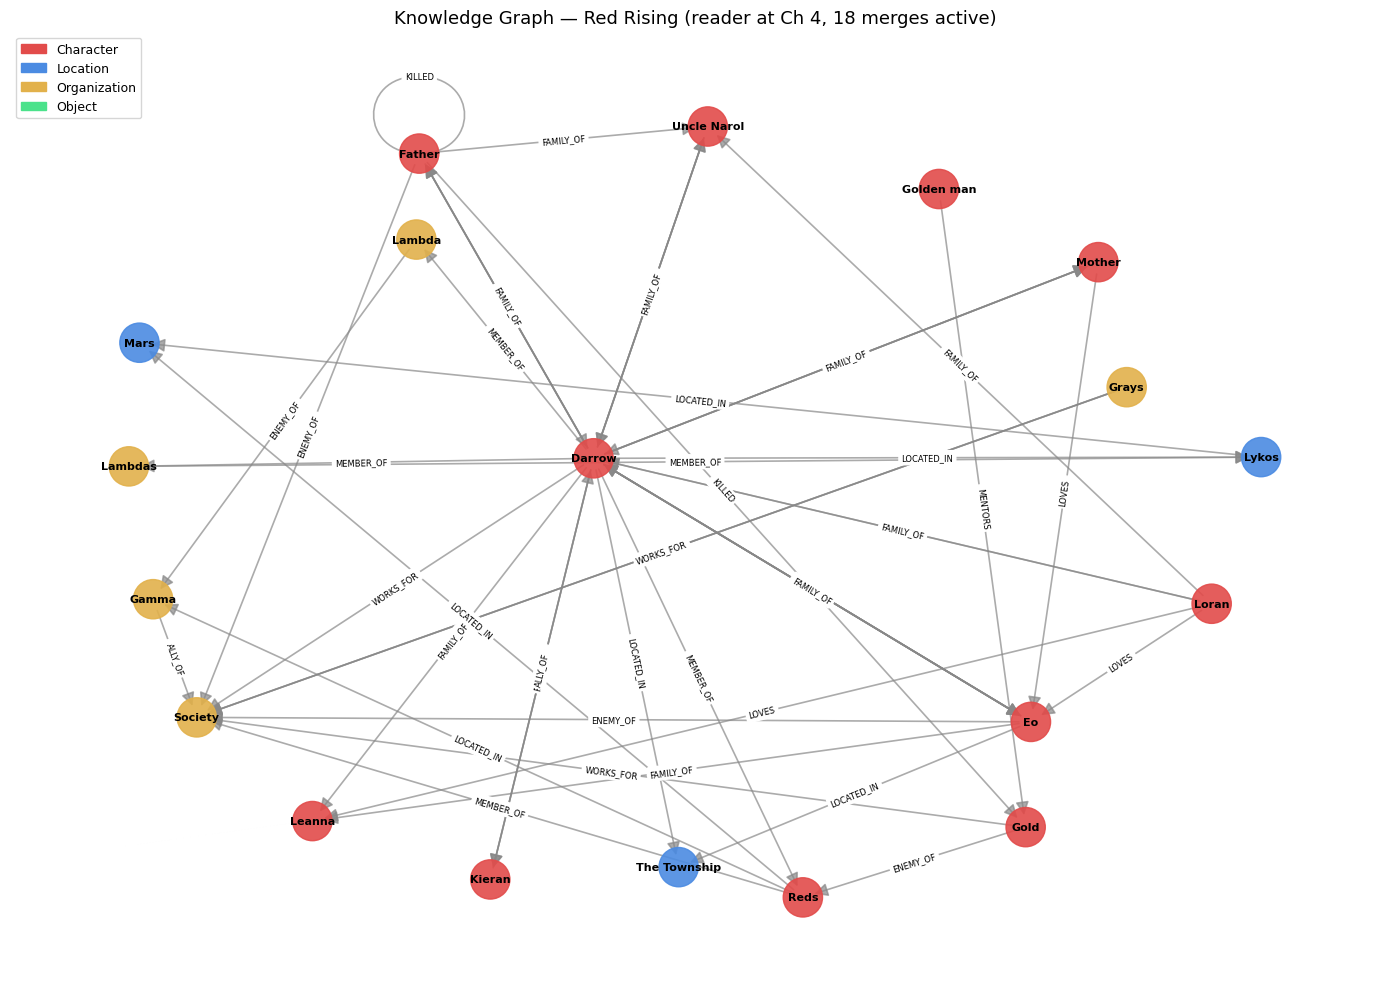

In [25]:
# Visualise the temporal graph — nodes with degree >= 2
important_nodes = {n for n, d in G.degree() if d >= 2}
H = G.subgraph(important_nodes).copy()

fig, ax = plt.subplots(figsize=(14, 10))

pos = nx.spring_layout(H, seed=42, k=2.5)

node_colors = [
    TYPE_COLORS.get(H.nodes[n].get("entity_type", "?"), "#aaa")
    for n in H.nodes()
]

nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=800, alpha=0.9, ax=ax)
nx.draw_networkx_labels(H, pos, font_size=8, font_weight="bold", ax=ax)
nx.draw_networkx_edges(
    H, pos, edge_color="#888", arrows=True,
    arrowsize=20, width=1.2, alpha=0.7, ax=ax
)

edge_labels = {(u, v): d["predicate"] for u, v, d in H.edges(data=True)}
nx.draw_networkx_edge_labels(H, pos, edge_labels=edge_labels, font_size=6, ax=ax)

legend_patches = [mpatches.Patch(color=c, label=t) for t, c in TYPE_COLORS.items()]
ax.legend(handles=legend_patches, loc="upper left", fontsize=9)

active = sum(1 for d in merge_table if d.safe_from_chapter <= READER_CHAPTER)
ax.set_title(
    f"Knowledge Graph — Red Rising (reader at Ch {READER_CHAPTER}, {active} merges active)",
    fontsize=13,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Part 8 — Hybrid Query & Generation

Now we combine both retrieval paths:

```
User Query
    │
    ├─── 1. Vector Search → passages (contextual, auto-merged scenes)
    │
    └─── 2. Graph Search → entity facts and relationship chains
              │
              └── Extract entities from query → traverse graph → collect facts
    │
    └─── 3. Fuse context → prompt Claude → answer
```

In [26]:
def extract_query_entities(query: str) -> List[str]:
    """Use Claude to extract entity names from the user's query."""
    response = client.messages.create(
        model="claude-haiku-4-5",
        max_tokens=100,
        messages=[
            {
                "role": "user",
                "content": (
                    f"Extract entity names (character names, place names, organization names) "
                    f"from this query about the book Red Rising.\n\n"
                    f"Query: {query}\n\n"
                    f"Return ONLY a JSON list of strings, e.g. [\"Darrow\", \"Eo\"]."
                )
            }
        ],
    )
    raw = response.content[0].text.strip()
    raw = re.sub(r"^```(?:json)?\n?", "", raw)
    raw = re.sub(r"\n?```$", "", raw)
    try:
        return json.loads(raw)
    except Exception:
        return []


def graph_search(query_entities: List[str], max_hops: int = 1) -> str:
    """
    Traverse the knowledge graph to collect facts about query entities.
    Returns a formatted string of facts.
    """
    facts = []
    visited_edges = set()

    for entity_name in query_entities:
        # Find the node (case-insensitive fuzzy match)
        matching_nodes = [
            n for n in G.nodes()
            if entity_name.lower() in n.lower() or n.lower() in entity_name.lower()
        ]

        for node in matching_nodes:
            desc = G.nodes[node].get("description", "")
            etype = G.nodes[node].get("entity_type", "Entity")
            if desc:
                facts.append(f"{node} ({etype}): {desc}")

            # Outgoing edges
            for _, target, data in G.out_edges(node, data=True):
                key = (node, target, data["predicate"])
                if key not in visited_edges:
                    facts.append(f"{node} --[{data['predicate']}]--> {target} (Ch {data['chapter']})")
                    visited_edges.add(key)

            # Incoming edges
            for source, _, data in G.in_edges(node, data=True):
                key = (source, node, data["predicate"])
                if key not in visited_edges:
                    facts.append(f"{source} --[{data['predicate']}]--> {node} (Ch {data['chapter']})")
                    visited_edges.add(key)

    return "\n".join(facts) if facts else "No graph facts found."


def hybrid_retrieve(query: str, vector_k: int = 6, merge_threshold: int = 2) -> Dict:
    """Run both vector and graph retrieval, return combined context."""
    # 1. Vector retrieval
    vector_nodes = retrieve(query, top_k=vector_k, merge_threshold=merge_threshold)
    vector_context = "\n\n---\n\n".join(
        f"[{n.level.upper()} — Ch {n.chapter_index}: {n.chapter_label}]\n{n.text[:600]}"
        for n in vector_nodes
    )

    # 2. Graph retrieval
    query_entities = extract_query_entities(query)
    graph_facts = graph_search(query_entities)

    return {
        "vector_context": vector_context,
        "graph_facts": graph_facts,
        "query_entities": query_entities,
        "retrieved_nodes": vector_nodes,
    }


# Test the hybrid retrieval
query = "What is Darrow's relationship with Eo?"
ctx = hybrid_retrieve(query)

print(f"Query: {query}")
print(f"Entities found: {ctx['query_entities']}")
print(f"\n--- Graph Facts ---")
print(ctx["graph_facts"])
print(f"\n--- Vector Context (first 400 chars) ---")
print(ctx["vector_context"][:400])

Query: What is Darrow's relationship with Eo?
Entities found: ['Darrow', 'Eo']

--- Graph Facts ---
Darrow (Character): Red miner, protagonist, tall with rust-red hair and angular face
Darrow --[FAMILY_OF]--> Father (Ch 1)
Darrow --[FAMILY_OF]--> Mother (Ch 1)
Darrow --[FAMILY_OF]--> Kieran (Ch 1)
Darrow --[FAMILY_OF]--> Leanna (Ch 1)
Darrow --[LOVES]--> Eo (Ch 1)
Darrow --[MEMBER_OF]--> Lambda (Ch 1)
Darrow --[WORKS_FOR]--> Uncle Narol (Ch 1)
Darrow --[FAMILY_OF]--> Uncle Narol (Ch 3)
Darrow --[MEMBER_OF]--> Lambdas (Ch 2)
Darrow --[WORKS_FOR]--> Society (Ch 2)
Darrow --[LOCATED_IN]--> The Township (Ch 2)
Darrow --[MEMBER_OF]--> Reds (Ch 3)
Darrow --[LOCATED_IN]--> Lykos (Ch 3)
Uncle Narol --[FAMILY_OF]--> Darrow (Ch 1)
Uncle Narol --[MENTORS]--> Darrow (Ch 3)
Loran --[FAMILY_OF]--> Darrow (Ch 1)
Eo --[FAMILY_OF]--> Darrow (Ch 2)
Eo --[LOVES]--> Darrow (Ch 4)
Kieran --[ALLY_OF]--> Darrow (Ch 2)
Dago --[ENEMY_OF]--> Darrow (Ch 2)
Ugly Dan --[ENEMY_OF]--> Darrow (Ch 2)
Mother --[MENTORS

In [27]:
GENERATION_PROMPT = """\
You are a reading companion for "Red Rising" by Pierce Brown. \
Think of yourself as a friend who has read the book and is talking with someone who is reading it now. \
Answer their question naturally, the way you would explain something to a friend over coffee — \
no bullet points, no headers, no structured lists unless the question is genuinely asking you \
to compare or list multiple distinct things. Just talk to them.

Match your answer length to the question. Default to short — two or three sentences for most questions. \
Only go longer if the person is explicitly asking you to explain something in depth, \
walk through an event, or explore a theme. If they ask "who is X" or "what is X", \
give them the essential answer and stop. They'll ask follow-up questions if they want more.

Draw on the facts and passages below to make your answer accurate, \
but weave them in naturally rather than citing them mechanically. \
If a chapter detail matters, mention it in passing ("early on..." or "right from the start..."). \
If the context doesn't give you enough to answer well, say so plainly.

=== KNOWLEDGE GRAPH FACTS ===
{graph_facts}

=== NARRATIVE PASSAGES ===
{vector_context}

=== READER'S QUESTION ===
{query}
"""

def answer_question(query: str, verbose: bool = False) -> str:
    """End-to-end hybrid RAG: retrieve + generate."""
    ctx = hybrid_retrieve(query)

    if verbose:
        print(f"[Entities extracted]: {ctx['query_entities']}")
        print(f"[Nodes retrieved]: {[n.id for n in ctx['retrieved_nodes']]}")
        print()

    prompt = GENERATION_PROMPT.format(
        graph_facts=ctx["graph_facts"],
        vector_context=ctx["vector_context"],
        query=query,
    )

    response = client.messages.create(
        model="claude-sonnet-4-6",  # Sonnet for generation quality
        max_tokens=500,
        messages=[{"role": "user", "content": prompt}],
    )
    return response.content[0].text.strip()


# Run it!
# q = "What is Darrow's relationship with Eo?"
q = "Who is Eo?"
print(f"Q: {q}")
print()
answer = answer_question(q, verbose=True)
print("A:", answer)

Q: Who is Eo?

[Entities extracted]: ['Eo']
[Nodes retrieved]: ['ch003_sc02', 'ch002_sc03_p01', 'ch004_sc02_p20', 'ch004_sc03_p05', 'ch004_sc01_p11']

A: Eo is Darrow's wife — the love of his life, really. She's described as a dancer, full of spirit, with rusty red hair, and Darrow makes it pretty clear early on that she's the center of his world. There's even a sweet moment where he remembers falling in love with her watching her dance in a smoky tavern. She's also quietly rebellious — she's no fan of the Society that rules over them.


In [28]:
# Try a few more questions
questions = [
    "Who are the main factions in the society?",
    "What does Darrow do for a living at the start of the story?",
    "Describe the social hierarchy in this world.",
]

for q in questions:
    print(f"Q: {q}")
    print(f"A: {answer_question(q)}")
    print("-" * 60)

Q: Who are the main factions in the society?
A: The big one is the color hierarchy — basically everyone is born into a color that determines their role and status. Golds are at the top, ruling everything. Then you've got Grays, who are like enforcers and soldiers, Reds at the very bottom doing brutal labor like mining. There are others in between — Silvers, Obsidians, and so on — but the core tension Darrow is living right now is that Reds do the hard, dangerous work and get almost nothing for it, while the upper colors reap the rewards.
------------------------------------------------------------
Q: What does Darrow do for a living at the start of the story?
A: He's a miner — specifically a helium-3 driller working deep beneath the surface of Mars. He's part of the Red caste, the lowest rung of society, and he works under his Uncle Narol in a clan called Lambda.
------------------------------------------------------------
Q: Describe the social hierarchy in this world.
A: So the world

## Part 9 — What's Missing & What's Next

### What we built:
| Component | Status | Notes |
|-----------|--------|-------|
| Hierarchical chunking | ✅ | Chapter → Scene → Paragraph |
| Chapter summarization | ✅ | Claude Haiku |
| Contextual embeddings | ✅ | Summary prepended to leaf |
| In-memory vector index | ✅ | Numpy cosine similarity |
| Auto-merging retrieval | ✅ | Promote scene when ≥2 leaves match |
| Entity extraction | ✅ | Claude Haiku, JSON triples |
| Knowledge graph | ✅ | NetworkX in-memory |
| Hybrid retrieval | ✅ | Vector + Graph combined |
| End-to-end generation | ✅ | Claude Sonnet |

### What's missing for production:

1. **Persistent vector store** — Replace `NumpyVectorIndex` with Qdrant (already set up in the project)
2. **Persistent graph database** — Replace NetworkX with Neo4j (already running via docker-compose)
3. **BM25 hybrid search** — Combine dense embeddings with sparse keyword search (better recall)
4. **Spoiler safety** — Only retrieve from chapters ≤ reader's current position
5. **Full book processing** — Scale to all chapters (we only used first 5)
6. **Entity deduplication** — "Darrow" vs "the Helldiver" are the same character
7. **Reranking** — Use a cross-encoder to rerank retrieved passages before generation

### Next steps in this notebook:
```python
# Part 10: Plug in Qdrant for persistent vector storage
# Part 11: Plug in Neo4j for persistent graph storage  
# Part 12: Add BM25 hybrid search
# Part 13: Add spoiler-safety filter
# Part 14: Scale to full book
```

## Part 10 (Optional) — Qdrant Vector Store

The project already uses Qdrant Cloud. Let's swap our numpy index for Qdrant.
The key advantage: embeddings persist across runs and can scale to millions of vectors.

In [ ]:
# Uncomment to install qdrant client if not already installed
# !pip install qdrant-client --quiet

In [ ]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

QDRANT_URL = os.getenv("QDRANT_URL", "")
QDRANT_API_KEY = os.getenv("QDRANT_API_KEY", "")

COLLECTION_NAME = "hybrid_rag_experiment"
EMBEDDING_DIM = embed_model.get_sentence_embedding_dimension()

qdrant = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)

# Create collection (skip if already exists)
existing = [c.name for c in qdrant.get_collections().collections]
if COLLECTION_NAME not in existing:
    qdrant.create_collection(
        collection_name=COLLECTION_NAME,
        vectors_config=VectorParams(size=EMBEDDING_DIM, distance=Distance.COSINE),
    )
    print(f"Created collection: {COLLECTION_NAME}")
else:
    print(f"Collection already exists: {COLLECTION_NAME}")

In [ ]:
# Upload leaf node embeddings to Qdrant
# Each point stores: vector + payload (id, text, chapter_index, level, parent_id)
points = []
for i, node in enumerate(leaves_to_embed):
    if node.embedding is None:
        continue
    points.append(PointStruct(
        id=i,
        vector=node.embedding.tolist(),
        payload={
            "node_id": node.id,
            "text": node.text,
            "chapter_index": node.chapter_index,
            "chapter_label": node.chapter_label,
            "level": node.level,
            "parent_id": node.parent_id,
            "scene_index": node.scene_index,
        },
    ))

qdrant.upsert(collection_name=COLLECTION_NAME, points=points)
print(f"Uploaded {len(points)} vectors to Qdrant")

In [ ]:
def qdrant_search(query: str, top_k: int = 5, max_chapter: Optional[int] = None):
    """Search Qdrant with optional spoiler-safety filter."""
    q_vec = embed_model.encode([query])[0].tolist()

    # Optional: only retrieve from chapters up to reader's current position
    query_filter = None
    if max_chapter is not None:
        from qdrant_client.models import Filter, FieldCondition, Range
        query_filter = Filter(
            must=[FieldCondition(key="chapter_index", range=Range(lte=max_chapter))]
        )

    results = qdrant.search(
        collection_name=COLLECTION_NAME,
        query_vector=q_vec,
        limit=top_k,
        query_filter=query_filter,
        with_payload=True,
    )
    return results


# Test — with spoiler safety: only chapters 0-2
results = qdrant_search("Who is Darrow?", top_k=3, max_chapter=2)
for r in results:
    print(f"[{r.score:.3f}] Ch{r.payload['chapter_index']}: {r.payload['text'][:120]}...")

## Part 11 (Optional) — Neo4j Graph Store

The project has Neo4j running via `docker-compose.neo4j.yml`. Let's persist the extracted triples there.

In [ ]:
from neo4j import GraphDatabase

NEO4J_URI      = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER     = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "neo4j")

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
driver.verify_connectivity()
print("Connected to Neo4j")

In [ ]:
EXPERIMENT_SERIES = "hybrid_rag_experiment"  # Namespace so we don't pollute the main DB


def upsert_entity(tx, entity: Entity, series_id: str) -> None:
    tx.run(
        """
        MERGE (e:ExperimentEntity {name: $name, series_id: $series_id})
        SET e.entity_type = $entity_type,
            e.description = $description
        """,
        name=entity.name,
        series_id=series_id,
        entity_type=entity.entity_type,
        description=entity.description,
    )


def upsert_relation(tx, rel: Relation, series_id: str) -> None:
    # Dynamic relationship types require Cypher string interpolation — use APOC or inline
    # For safety we allow only known predicates
    ALLOWED = {"ALLY_OF", "ENEMY_OF", "FAMILY_OF", "KILLED", "LOCATED_IN",
               "MEMBER_OF", "BETRAYED", "LOVES", "MENTORS", "WORKS_FOR",
               "OWNS", "INTERACTED_WITH"}
    predicate = rel.predicate if rel.predicate in ALLOWED else "INTERACTED_WITH"

    query = f"""
        MATCH (a:ExperimentEntity {{name: $subject, series_id: $series_id}})
        MATCH (b:ExperimentEntity {{name: $obj, series_id: $series_id}})
        MERGE (a)-[r:{predicate}]->(b)
        SET r.chapter_index = $chapter_index,
            r.chunk_id = $chunk_id,
            r.context = $context
    """
    tx.run(
        query,
        subject=rel.subject,
        obj=rel.obj,
        series_id=series_id,
        chapter_index=rel.chapter_index,
        chunk_id=rel.chunk_id,
        context=rel.context,
    )


with driver.session() as session:
    # Write entities
    for entity in all_entities.values():
        session.execute_write(upsert_entity, entity, EXPERIMENT_SERIES)

    # Write relations
    for rel in all_relations:
        try:
            session.execute_write(upsert_relation, rel, EXPERIMENT_SERIES)
        except Exception as e:
            pass  # Skip if either endpoint doesn't exist

print(f"Written {len(all_entities)} entities and {len(all_relations)} relations to Neo4j")

In [ ]:
# Query Neo4j to verify
with driver.session() as session:
    result = session.run(
        """
        MATCH (a:ExperimentEntity {series_id: $s})-[r]->(b:ExperimentEntity {series_id: $s})
        RETURN a.name AS subject, type(r) AS predicate, b.name AS object, r.chapter_index AS chapter
        ORDER BY chapter
        LIMIT 15
        """,
        s=EXPERIMENT_SERIES,
    )
    rows = [dict(record) for record in result]

print(f"Relations in Neo4j:")
for row in rows:
    print(f"  Ch{row['chapter']}: {row['subject']} --[{row['predicate']}]--> {row['object']}")

driver.close()

## Summary

You've built a full Hybrid Graph-Vector RAG pipeline from scratch:

```
EPUB → Hierarchical Nodes → Chapter Summaries (Claude)
                                    │
                         Contextual Embeddings
                         ┌────────────────────┐
                         │   Vector Index     │ ← in-memory (numpy) or Qdrant
                         │  + Auto-Merging    │
                         └────────────────────┘
                                    │
                         Entity Extraction (Claude)
                         ┌────────────────────┐
                         │  Knowledge Graph   │ ← in-memory (networkx) or Neo4j
                         └────────────────────┘
                                    │
                         Hybrid Retrieve + Generate
                         (Claude Sonnet)
```

**Key learnings:**
- Hierarchical chunking lets retrieval operate at the right granularity
- Contextual embeddings solve the decontextualization problem
- Auto-merging returns full narrative scenes instead of isolated sentences
- Knowledge graphs handle relational queries that pure vector search struggles with
- Hybrid retrieval combines the strengths of both approaches